<a href="https://colab.research.google.com/github/IMxARVIND/IPL-2027-Schedule-Prediction/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("IPL 2027 ML Project Started")

IPL 2027 ML Project Started


In [8]:
import pandas as pd

df = pd.read_csv("ipl-2026-UTC.csv")

print("Dataset Loaded Successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully!
Rows: 74
Columns: 7

Column Names:
['Match Number', 'Round Number', 'Date', 'Location', 'Home Team', 'Away Team', 'Result']

First 5 Rows:


,Match Number,Round Number,Date,Location,Home Team,Away Team,Result
0,1,1,28/03/2026 14:00,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,NaN
1,2,1,29/03/2026 14:00,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,NaN
2,3,1,30/03/2026 14:00,ACA Stadium,Rajasthan Royals,Chennai Super Kings,NaN
3,4,1,31/03/2026 14:00,New International Cricket Stadium,Punjab Kings,Gujarat Titans,NaN
4,5,1,1/4/2026 14:00,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,NaN


In [9]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Match Number  74 non-null     int64  
 1   Round Number  74 non-null     object 
 2   Date          74 non-null     object 
 3   Location      74 non-null     object 
 4   Home Team     74 non-null     object 
 5   Away Team     74 non-null     object 
 6   Result        0 non-null      float64
dtypes: float64(1), int64(1), object(5)
memory usage: 4.2+ KB
None

Missing Values:
Match Number     0
Round Number     0
Date             0
Location         0
Home Team        0
Away Team        0
Result          74
dtype: int64


In [26]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)


print("Result Missing Values:")
if "Result" in df.columns:
    print(df["Result"].isnull().sum())
    df = df.drop(columns=["Result"], errors='ignore')
else:
    print("Result column not found, skipped missing value check and dropping.")


df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("\nCleaned Dataset:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

Result Missing Values:
Result column not found, skipped missing value check and dropping.

Cleaned Dataset:


,Match Number,Round Number,Date,Location,Home Team,Away Team,Year,Month,Day,DayOfWeek
0,1,1,2026-03-28 14:00:00,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,2026,3,28,5
1,2,1,2026-03-29 14:00:00,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,2026,3,29,6
2,3,1,2026-03-30 14:00:00,ACA Stadium,Rajasthan Royals,Chennai Super Kings,2026,3,30,0
3,4,1,2026-03-31 14:00:00,New International Cricket Stadium,Punjab Kings,Gujarat Titans,2026,3,31,1
4,5,1,2026-04-01 14:00:00,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,2026,4,1,2



Dataset Shape:
(74, 10)


IPL 2026 Team-wise Match Analysis
Gujarat Titans                 17
Rajasthan Royals               16
Royal Challengers Bengaluru    16
Sunrisers Hyderabad            15
Delhi Capitals                 14
Chennai Super Kings            14
Mumbai Indians                 14
Lucknow Super Giants           14
Kolkata Knight Riders          14
Punjab Kings                   14
Name: count, dtype: int64


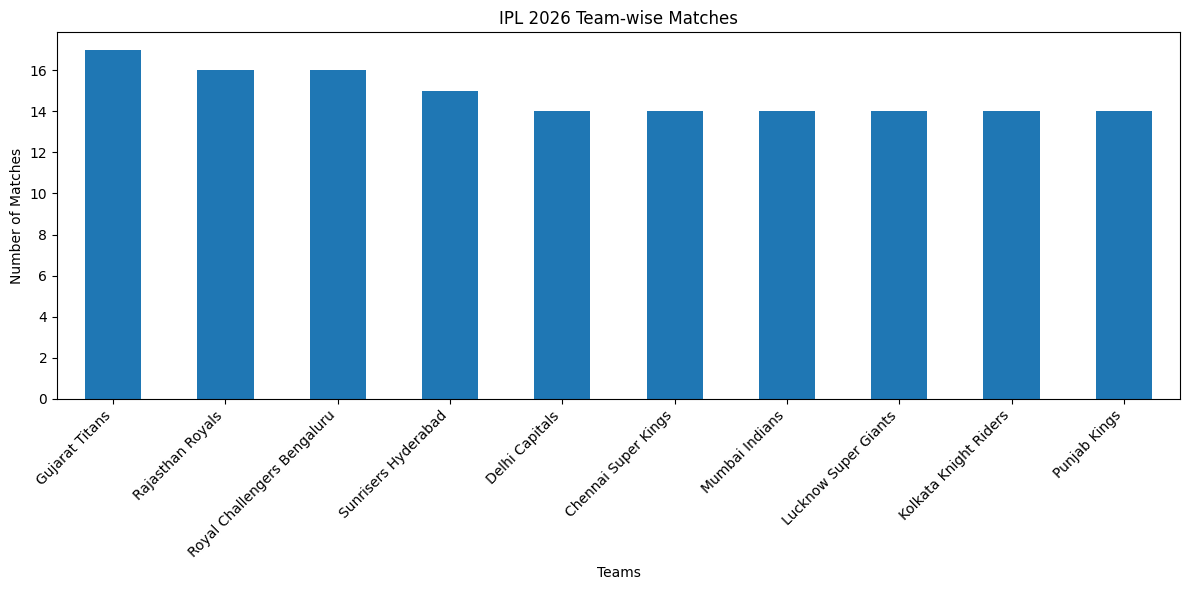

In [11]:


import pandas as pd
import matplotlib.pyplot as plt


home_matches = df["Home Team"].value_counts()
away_matches = df["Away Team"].value_counts()


team_matches = home_matches.add(
    away_matches, fill_value=0
).astype(int)


team_matches = team_matches.sort_values(ascending=False)

print("IPL 2026 Team-wise Match Analysis")
print(team_matches)


plt.figure(figsize=(12, 6))

team_matches.plot(kind="bar")

plt.title("IPL 2026 Team-wise Matches")
plt.xlabel("Teams")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

IPL 2026 Stadium-wise Matches
Location
Narendra Modi Stadium                                 8
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Crick    7
MA Chidambaram Stadium                                7
Eden Gardens                                          7
Wankhede Stadium                                      7
Rajiv Gandhi International Stadium                    7
Arun Jaitley Stadium                                  7
New International Cricket Stadium                     6
M Chinnaswamy Stadium                                 5
Himachal Pradesh Cricket Association Stadium          4
Sawai Mansingh Stadium                                4
ACA Stadium                                           3
Shaheed Veer Narayan Singh International Cricket S    2
Name: count, dtype: int64


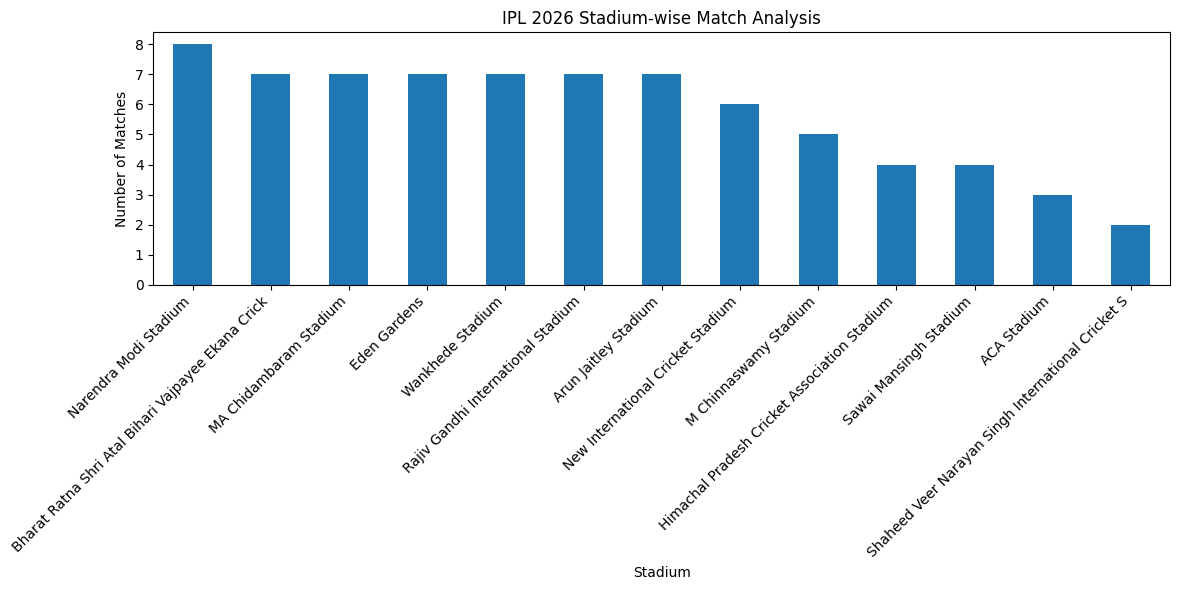

In [12]:


stadium_matches = df["Location"].value_counts()

print("IPL 2026 Stadium-wise Matches")
print(stadium_matches)

# Stadium-wise Bar Chart
plt.figure(figsize=(12, 6))

stadium_matches.plot(kind="bar")

plt.title("IPL 2026 Stadium-wise Match Analysis")
plt.xlabel("Stadium")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Month-wise Match Count:
Month
3     4
4    38
5    32
Name: count, dtype: int64


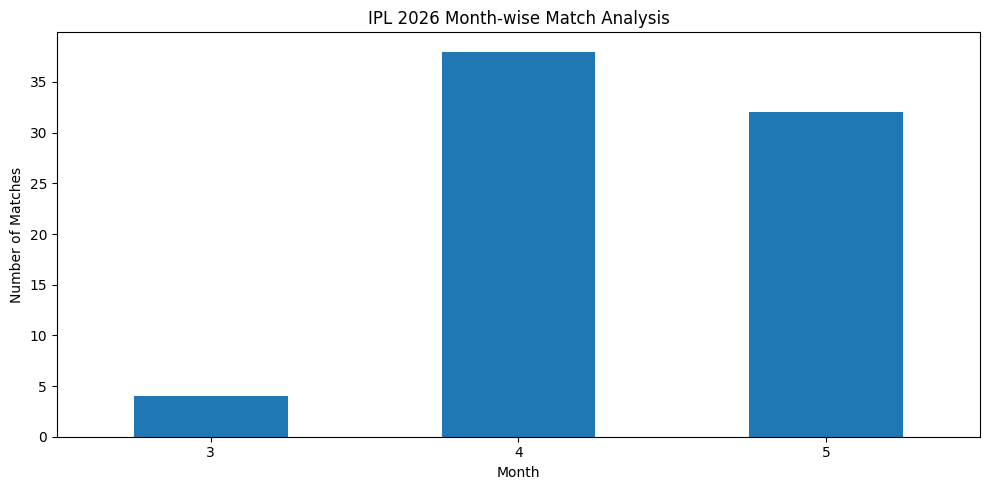

In [13]:


import matplotlib.pyplot as plt


month_matches = df["Month"].value_counts().sort_index()

print("Month-wise Match Count:")
print(month_matches)

# Bar Chart
plt.figure(figsize=(10, 5))

month_matches.plot(kind="bar")

plt.title("IPL 2026 Month-wise Match Analysis")
plt.xlabel("Month")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Round-wise Match Count:
Round Number
 Preliminary Finals      2
1                        9
2                        9
3                        9
4                        9
5                        8
6                        8
7                        8
8                       10
Final                    1
Qualifier 2              1
Name: count, dtype: int64


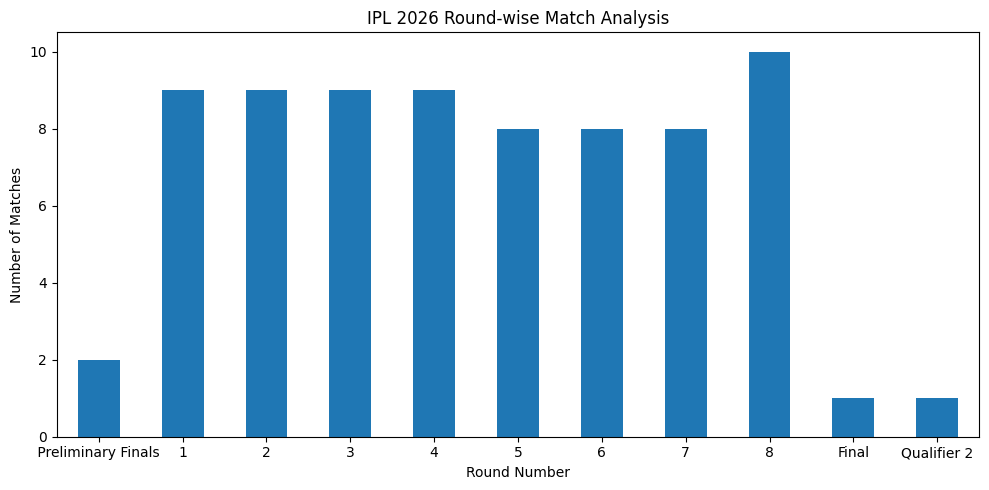

In [14]:


round_matches = df["Round Number"].value_counts().sort_index()

print("Round-wise Match Count:")
print(round_matches)

# Bar Chart
plt.figure(figsize=(10, 5))

round_matches.plot(kind="bar")

plt.title("IPL 2026 Round-wise Match Analysis")
plt.xlabel("Round Number")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:


import pandas as pd


print("Dataset Shape:", df.shape)

print("\nAvailable Columns:")
print(df.columns.tolist())


required_columns = [
    "Date",
    "Location",
    "Home Team",
    "Away Team",
    "Round Number"
]

print("\nRequired Columns Check:")
for col in required_columns:
    if col in df.columns:
        print(f"{col}: Available")
    else:
        print(f"{col}: Missing")


if "Result" in df.columns:
    print("\nResult Column:")
    print(df["Result"].value_counts(dropna=False))
else:
    print("\nResult column is not available.")


print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Preview:")
display(df.head(10))

Dataset Shape: (74, 10)

Available Columns:
['Match Number', 'Round Number', 'Date', 'Location', 'Home Team', 'Away Team', 'Year', 'Month', 'Day', 'DayOfWeek']

Required Columns Check:
Date: Available
Location: Available
Home Team: Available
Away Team: Available
Round Number: Available

Result column is not available.

Missing Values:
Match Number    0
Round Number    0
Date            0
Location        0
Home Team       0
Away Team       0
Year            0
Month           0
Day             0
DayOfWeek       0
dtype: int64

Dataset Preview:


,Match Number,Round Number,Date,Location,Home Team,Away Team,Year,Month,Day,DayOfWeek
0,1,1,2026-03-28 14:00:00,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,2026,3,28,5
1,2,1,2026-03-29 14:00:00,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,2026,3,29,6
2,3,1,2026-03-30 14:00:00,ACA Stadium,Rajasthan Royals,Chennai Super Kings,2026,3,30,0
3,4,1,2026-03-31 14:00:00,New International Cricket Stadium,Punjab Kings,Gujarat Titans,2026,3,31,1
4,5,1,2026-04-01 14:00:00,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,2026,4,1,2
5,6,1,2026-04-02 14:00:00,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,2026,4,2,3
6,7,1,2026-04-03 14:00:00,MA Chidambaram Stadium,Chennai Super Kings,Punjab Kings,2026,4,3,4
7,8,1,2026-04-04 10:00:00,Arun Jaitley Stadium,Delhi Capitals,Mumbai Indians,2026,4,4,5
8,9,1,2026-04-04 14:00:00,Narendra Modi Stadium,Gujarat Titans,Rajasthan Royals,2026,4,4,5
9,10,2,2026-04-05 10:00:00,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Lucknow Super Giants,2026,4,5,6


In [16]:


import pandas as pd


ipl_df = df.copy()


ipl_df["Season"] = 2026

ipl_df["Home Team"] = ipl_df["Home Team"].str.strip()
ipl_df["Away Team"] = ipl_df["Away Team"].str.strip()

ipl_df["Team Pair"] = (
    ipl_df["Home Team"] + " vs " + ipl_df["Away Team"]
)


ipl_df["Day Name"] = ipl_df["Date"].dt.day_name()


final_columns = [
    "Season",
    "Match Number",
    "Round Number",
    "Date",
    "Month",
    "Day",
    "Day Name",
    "Location",
    "Home Team",
    "Away Team",
    "Team Pair"
]

ipl_df = ipl_df[final_columns]

print("IPL ML Dataset Created!")
print("Dataset Shape:", ipl_df.shape)

display(ipl_df.head(10))


ipl_df.to_csv("ipl_2026_ml_dataset.csv", index=False)

print("Dataset saved successfully!")

IPL ML Dataset Created!
Dataset Shape: (74, 11)


,Season,Match Number,Round Number,Date,Month,Day,Day Name,Location,Home Team,Away Team,Team Pair
0,2026,1,1,2026-03-28 14:00:00,3,28,Saturday,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru vs Sunrisers Hyder...
1,2026,2,1,2026-03-29 14:00:00,3,29,Sunday,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians vs Kolkata Knight Riders
2,2026,3,1,2026-03-30 14:00:00,3,30,Monday,ACA Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals vs Chennai Super Kings
3,2026,4,1,2026-03-31 14:00:00,3,31,Tuesday,New International Cricket Stadium,Punjab Kings,Gujarat Titans,Punjab Kings vs Gujarat Titans
4,2026,5,1,2026-04-01 14:00:00,4,1,Wednesday,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,Lucknow Super Giants vs Delhi Capitals
5,2026,6,1,2026-04-02 14:00:00,4,2,Thursday,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders vs Sunrisers Hyderabad
6,2026,7,1,2026-04-03 14:00:00,4,3,Friday,MA Chidambaram Stadium,Chennai Super Kings,Punjab Kings,Chennai Super Kings vs Punjab Kings
7,2026,8,1,2026-04-04 10:00:00,4,4,Saturday,Arun Jaitley Stadium,Delhi Capitals,Mumbai Indians,Delhi Capitals vs Mumbai Indians
8,2026,9,1,2026-04-04 14:00:00,4,4,Saturday,Narendra Modi Stadium,Gujarat Titans,Rajasthan Royals,Gujarat Titans vs Rajasthan Royals
9,2026,10,2,2026-04-05 10:00:00,4,5,Sunday,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Lucknow Super Giants,Sunrisers Hyderabad vs Lucknow Super Giants


Dataset saved successfully!


In [17]:


import pandas as pd

# Date column convert to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 1. Dataset information
print("Dataset Shape:", df.shape)
print("\nTotal Matches:", len(df))

# 2. Unique Teams
teams = sorted(set(df["Home Team"].dropna()) |
               set(df["Away Team"].dropna()))

print("\nTotal Teams:", len(teams))
print("\nTeam List:")
for team in teams:
    print(team)

# 3. Venue Analysis
print("\nTotal Venues:", df["Location"].nunique())
print("\nVenue-wise Match Count:")
print(df["Location"].value_counts())

# 4. Home Team Match Count
print("\nHome Team Matches:")
print(df["Home Team"].value_counts())

# 5. Away Team Match Count
print("\nAway Team Matches:")
print(df["Away Team"].value_counts())

# 6. Date Range
print("\nFirst Match:", df["Date"].min())
print("Last Match:", df["Date"].max())

# 7. Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (74, 10)

Total Matches: 74

Total Teams: 10

Team List:
Chennai Super Kings
Delhi Capitals
Gujarat Titans
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Punjab Kings
Rajasthan Royals
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total Venues: 13

Venue-wise Match Count:
Location
Narendra Modi Stadium                                 8
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Crick    7
MA Chidambaram Stadium                                7
Eden Gardens                                          7
Wankhede Stadium                                      7
Rajiv Gandhi International Stadium                    7
Arun Jaitley Stadium                                  7
New International Cricket Stadium                     6
M Chinnaswamy Stadium                                 5
Himachal Pradesh Cricket Association Stadium          4
Sawai Mansingh Stadium                                4
ACA Stadium                                           3
Shaheed Veer Naray

In [18]:
# Step 1: Create estimated IPL 2027 dataset

import pandas as pd

# Original dataset copy
df_2027 = df.copy()

# Convert Date column to datetime
df_2027["Date"] = pd.to_datetime(df_2027["Date"])

# Shift dates by 364 days to preserve weekdays
df_2027["Date"] = df_2027["Date"] + pd.Timedelta(days=364)

# Update season and date-related columns
df_2027["Season"] = 2027
df_2027["Month"] = df_2027["Date"].dt.month
df_2027["Day"] = df_2027["Date"].dt.day
df_2027["Day Name"] = df_2027["Date"].dt.day_name()

# Recreate team pair
df_2027["Team Pair"] = (
    df_2027["Home Team"] + " vs " + df_2027["Away Team"]
)

# Display the estimated 2027 dataset
print("Estimated IPL 2027 Dataset Created!")
print("Dataset Shape:", df_2027.shape)

display(df_2027.head(10))

# Save as CSV
df_2027.to_csv("IPL_2027_Estimated_Dataset.csv", index=False)

print("2027 dataset saved successfully!")

Estimated IPL 2027 Dataset Created!
Dataset Shape: (74, 13)


,Match Number,Round Number,Date,Location,Home Team,Away Team,Year,Month,Day,DayOfWeek,Season,Day Name,Team Pair
0,1,1,2027-03-27 14:00:00,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,2026,3,27,5,2027,Saturday,Royal Challengers Bengaluru vs Sunrisers Hyder...
1,2,1,2027-03-28 14:00:00,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,2026,3,28,6,2027,Sunday,Mumbai Indians vs Kolkata Knight Riders
2,3,1,2027-03-29 14:00:00,ACA Stadium,Rajasthan Royals,Chennai Super Kings,2026,3,29,0,2027,Monday,Rajasthan Royals vs Chennai Super Kings
3,4,1,2027-03-30 14:00:00,New International Cricket Stadium,Punjab Kings,Gujarat Titans,2026,3,30,1,2027,Tuesday,Punjab Kings vs Gujarat Titans
4,5,1,2027-03-31 14:00:00,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,2026,3,31,2,2027,Wednesday,Lucknow Super Giants vs Delhi Capitals
5,6,1,2027-04-01 14:00:00,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,2026,4,1,3,2027,Thursday,Kolkata Knight Riders vs Sunrisers Hyderabad
6,7,1,2027-04-02 14:00:00,MA Chidambaram Stadium,Chennai Super Kings,Punjab Kings,2026,4,2,4,2027,Friday,Chennai Super Kings vs Punjab Kings
7,8,1,2027-04-03 10:00:00,Arun Jaitley Stadium,Delhi Capitals,Mumbai Indians,2026,4,3,5,2027,Saturday,Delhi Capitals vs Mumbai Indians
8,9,1,2027-04-03 14:00:00,Narendra Modi Stadium,Gujarat Titans,Rajasthan Royals,2026,4,3,5,2027,Saturday,Gujarat Titans vs Rajasthan Royals
9,10,2,2027-04-04 10:00:00,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Lucknow Super Giants,2026,4,4,6,2027,Sunday,Sunrisers Hyderabad vs Lucknow Super Giants


2027 dataset saved successfully!


Dataset Shape: (74, 13)

Column Names:
['Match Number', 'Round Number', 'Date', 'Location', 'Home Team', 'Away Team', 'Year', 'Month', 'Day', 'DayOfWeek', 'Season', 'Day Name', 'Team Pair']

2027 Estimated Schedule:
First Match: 2027-03-27 14:00:00
Last Match: 2027-05-30 14:00:00

Matches by Month:
Month
3     5
4    38
5    31
Name: count, dtype: int64


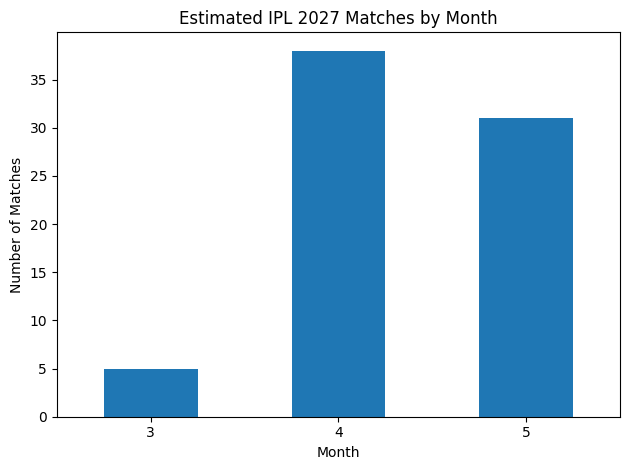


Matches by Day:
Day Name
Sunday       18
Saturday     13
Tuesday       9
Friday        9
Wednesday     9
Monday        8
Thursday      8
Name: count, dtype: int64


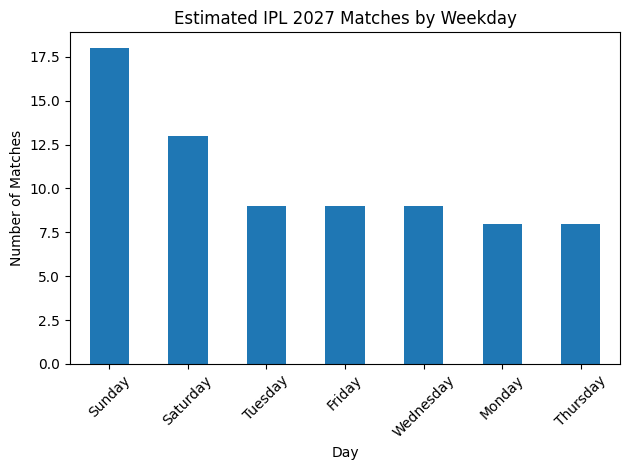


Home Matches by Team:
Home Team
Royal Challengers Bengaluru    9
Gujarat Titans                 8
Sunrisers Hyderabad            8
Mumbai Indians                 7
Rajasthan Royals               7
Punjab Kings                   7
Kolkata Knight Riders          7
Lucknow Super Giants           7
Delhi Capitals                 7
Chennai Super Kings            7
Name: count, dtype: int64


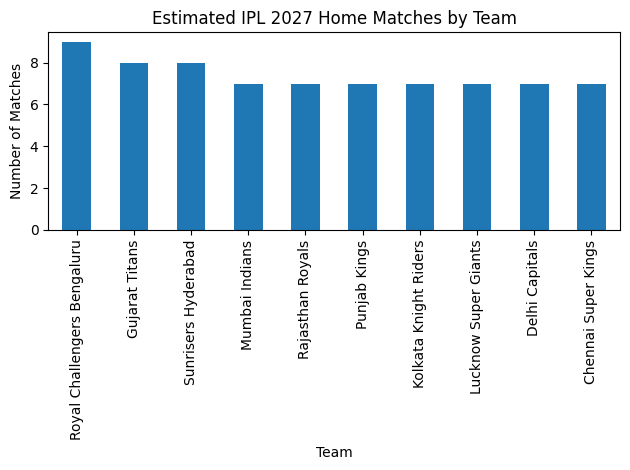

In [19]:
# Step 2: Analyze Estimated IPL 2027 Dataset

import pandas as pd
import matplotlib.pyplot as plt

# Check dataset information
print("Dataset Shape:", df_2027.shape)
print("\nColumn Names:")
print(df_2027.columns.tolist())

# Check date range
print("\n2027 Estimated Schedule:")
print("First Match:", df_2027["Date"].min())
print("Last Match:", df_2027["Date"].max())

# Matches by month
monthly_matches = df_2027["Month"].value_counts().sort_index()

print("\nMatches by Month:")
print(monthly_matches)

monthly_matches.plot(kind="bar")
plt.title("Estimated IPL 2027 Matches by Month")
plt.xlabel("Month")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Matches by weekday
weekday_matches = df_2027["Day Name"].value_counts()

print("\nMatches by Day:")
print(weekday_matches)

weekday_matches.plot(kind="bar")
plt.title("Estimated IPL 2027 Matches by Weekday")
plt.xlabel("Day")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Matches played by each home team
home_counts = df_2027["Home Team"].value_counts()

print("\nHome Matches by Team:")
print(home_counts)

home_counts.plot(kind="bar")
plt.title("Estimated IPL 2027 Home Matches by Team")
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Dataset Shape: (74, 13)

Missing Values:
Match Number    0
Round Number    0
Date            0
Location        0
Home Team       0
Away Team       0
Year            0
Month           0
Day             0
DayOfWeek       0
Season          0
Day Name        0
Team Pair       0
dtype: int64

Duplicate Matches: 0

Team-wise Match Analysis:


,Home Matches,Away Matches,Total Matches
Gujarat Titans,8,9,17
Rajasthan Royals,7,9,16
Royal Challengers Bengaluru,9,7,16
Sunrisers Hyderabad,8,7,15
Delhi Capitals,7,7,14
Chennai Super Kings,7,7,14
Mumbai Indians,7,7,14
Lucknow Super Giants,7,7,14
Kolkata Knight Riders,7,7,14
Punjab Kings,7,7,14


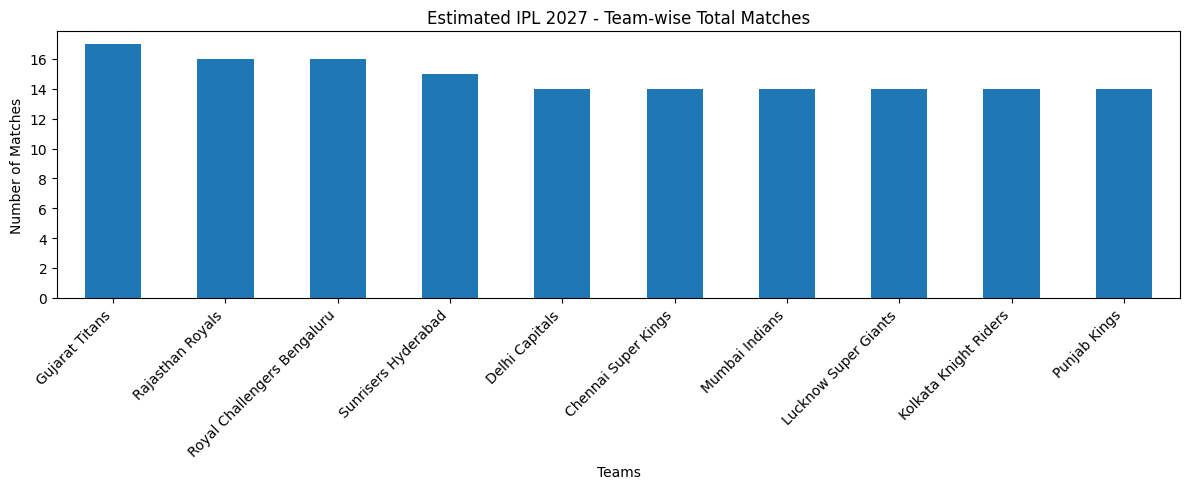


Validation and analysis completed!
Files saved successfully!


In [20]:
# Step 3: Dataset Validation and Team-wise Analysis

import pandas as pd
import matplotlib.pyplot as plt

# 1. Check dataset size
print("Dataset Shape:", df_2027.shape)

# 2. Check missing values
print("\nMissing Values:")
print(df_2027.isnull().sum())

# 3. Check duplicate matches
duplicate_matches = df_2027.duplicated(
    subset=["Date", "Home Team", "Away Team"]
).sum()

print("\nDuplicate Matches:", duplicate_matches)

# 4. Calculate home and away matches
home_matches = df_2027["Home Team"].value_counts()
away_matches = df_2027["Away Team"].value_counts()

team_analysis = pd.DataFrame({
    "Home Matches": home_matches,
    "Away Matches": away_matches
}).fillna(0).astype(int)

team_analysis["Total Matches"] = (
    team_analysis["Home Matches"] +
    team_analysis["Away Matches"]
)

team_analysis = team_analysis.sort_values(
    "Total Matches", ascending=False
)

print("\nTeam-wise Match Analysis:")
display(team_analysis)

# 5. Plot team-wise total matches
team_analysis["Total Matches"].plot(
    kind="bar", figsize=(12, 5)
)

plt.title("Estimated IPL 2027 - Team-wise Total Matches")
plt.xlabel("Teams")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 6. Save team analysis
team_analysis.to_csv("IPL_2027_Team_Analysis.csv")

# 7. Save validated dataset
df_2027.to_csv("IPL_2027_Validated_Dataset.csv", index=False)

print("\nValidation and analysis completed!")
print("Files saved successfully!")

In [21]:
# Step 4: Prepare Final IPL 2027 Projected Dataset

import pandas as pd

# Create a separate final dataset
final_2027 = df_2027.copy()

# Sort matches by date
final_2027["Date"] = pd.to_datetime(final_2027["Date"])
final_2027 = final_2027.sort_values("Date").reset_index(drop=True)

# Generate unique match IDs
final_2027["Match ID"] = [
    f"IPL2027_{i:03d}" for i in range(1, len(final_2027) + 1)
]

# Add projection status
final_2027["Data Status"] = "Estimated - Not Official"

# Add season column if missing
if "Season" not in final_2027.columns:
    final_2027["Season"] = 2027

# Arrange important columns first
preferred_columns = [
    "Match ID", "Season", "Match Number", "Round Number",
    "Date", "Month", "Day", "Day Name", "Location",
    "Home Team", "Away Team", "Team Pair", "Data Status"
]

available_columns = [
    col for col in preferred_columns if col in final_2027.columns
]

other_columns = [
    col for col in final_2027.columns if col not in available_columns
]

final_2027 = final_2027[available_columns + other_columns]

# Display final dataset
print("Final IPL 2027 Projected Dataset")
print("Rows and Columns:", final_2027.shape)
display(final_2027.head(10))

# Validate dates and match IDs
print("\nDuplicate Match IDs:", final_2027["Match ID"].duplicated().sum())
print("Missing Dates:", final_2027["Date"].isna().sum())
print("Total Matches:", len(final_2027))

# Save final dataset
final_2027.to_csv("IPL_2027_Final_Projected_Dataset.csv", index=False)

print("\nFinal dataset saved successfully!")

Final IPL 2027 Projected Dataset
Rows and Columns: (74, 15)


,Match ID,Season,Match Number,Round Number,Date,Month,Day,Day Name,Location,Home Team,Away Team,Team Pair,Data Status,Year,DayOfWeek
0,IPL2027_001,2027,1,1,2027-03-27 14:00:00,3,27,Saturday,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru vs Sunrisers Hyder...,Estimated - Not Official,2026,5
1,IPL2027_002,2027,2,1,2027-03-28 14:00:00,3,28,Sunday,Wankhede Stadium,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians vs Kolkata Knight Riders,Estimated - Not Official,2026,6
2,IPL2027_003,2027,3,1,2027-03-29 14:00:00,3,29,Monday,ACA Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals vs Chennai Super Kings,Estimated - Not Official,2026,0
3,IPL2027_004,2027,4,1,2027-03-30 14:00:00,3,30,Tuesday,New International Cricket Stadium,Punjab Kings,Gujarat Titans,Punjab Kings vs Gujarat Titans,Estimated - Not Official,2026,1
4,IPL2027_005,2027,5,1,2027-03-31 14:00:00,3,31,Wednesday,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Delhi Capitals,Lucknow Super Giants vs Delhi Capitals,Estimated - Not Official,2026,2
5,IPL2027_006,2027,6,1,2027-04-01 14:00:00,4,1,Thursday,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders vs Sunrisers Hyderabad,Estimated - Not Official,2026,3
6,IPL2027_007,2027,7,1,2027-04-02 14:00:00,4,2,Friday,MA Chidambaram Stadium,Chennai Super Kings,Punjab Kings,Chennai Super Kings vs Punjab Kings,Estimated - Not Official,2026,4
7,IPL2027_008,2027,8,1,2027-04-03 10:00:00,4,3,Saturday,Arun Jaitley Stadium,Delhi Capitals,Mumbai Indians,Delhi Capitals vs Mumbai Indians,Estimated - Not Official,2026,5
8,IPL2027_009,2027,9,1,2027-04-03 14:00:00,4,3,Saturday,Narendra Modi Stadium,Gujarat Titans,Rajasthan Royals,Gujarat Titans vs Rajasthan Royals,Estimated - Not Official,2026,5
9,IPL2027_010,2027,10,2,2027-04-04 10:00:00,4,4,Sunday,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Lucknow Super Giants,Sunrisers Hyderabad vs Lucknow Super Giants,Estimated - Not Official,2026,6



Duplicate Match IDs: 0
Missing Dates: 0
Total Matches: 74

Final dataset saved successfully!


In [22]:
# Step 5: Check Dataset Readiness for Machine Learning

import pandas as pd

# Use the final projected dataset
ml_data = final_2027.copy()

# 1. Check columns
print("Dataset Columns:")
print(ml_data.columns.tolist())

# 2. Check available seasons
if "Season" in ml_data.columns:
    print("\nAvailable Seasons:")
    print(sorted(ml_data["Season"].dropna().unique()))
else:
    print("\nSeason column not found.")

# 3. Check for match result / winner columns
possible_targets = [
    "Result", "Winner", "Match Winner",
    "Winning Team", "Winner Team"
]

target_columns = [
    col for col in possible_targets if col in ml_data.columns
]

print("\nAvailable Result Columns:", target_columns)

# 4. Check missing values
print("\nMissing Values:")
print(ml_data.isnull().sum())

# 5. Determine ML readiness
if target_columns:
    target = target_columns[0]
    print(f"\nTarget column found: {target}")
    print("Target values:")
    print(ml_data[target].value_counts(dropna=False))
else:
    print("\nNo match-result target column found.")

if "Season" in ml_data.columns:
    season_count = ml_data["Season"].nunique()
    print("\nNumber of seasons:", season_count)

    if season_count < 2:
        print("More historical seasons are needed for reliable ML training.")

if not target_columns:
    print(
        "\nNEXT REQUIREMENT: Upload historical IPL match data "
        "with Season, Home Team, Away Team, Date and Winner/Result."
    )

Dataset Columns:
['Match ID', 'Season', 'Match Number', 'Round Number', 'Date', 'Month', 'Day', 'Day Name', 'Location', 'Home Team', 'Away Team', 'Team Pair', 'Data Status', 'Year', 'DayOfWeek']

Available Seasons:
[np.int64(2027)]

Available Result Columns: []

Missing Values:
Match ID        0
Season          0
Match Number    0
Round Number    0
Date            0
Month           0
Day             0
Day Name        0
Location        0
Home Team       0
Away Team       0
Team Pair       0
Data Status     0
Year            0
DayOfWeek       0
dtype: int64

No match-result target column found.

Number of seasons: 1
More historical seasons are needed for reliable ML training.

NEXT REQUIREMENT: Upload historical IPL match data with Season, Home Team, Away Team, Date and Winner/Result.


In [23]:
# STEP 6: Prepare Features for ML

import pandas as pd

# 2026 data = Training Data
train_data = df.copy()

# 2027 data = Prediction Data
prediction_data = final_2027.copy()

# Required features
features = [
    "Home Team",
    "Away Team",
    "Month",
    "Day",
    "DayOfWeek",
    "Round Number"
]

# Input features
X_train = train_data[features].copy()
X_2027 = prediction_data[features].copy()

# Target = Venue / Location
y_train = train_data["Location"].copy()

print("Training Data Shape:", X_train.shape)
print("2027 Prediction Data Shape:", X_2027.shape)

print("\nFeatures:")
print(features)

print("\nTarget:")
print("Location")

print("\nTraining Data Preview:")
display(X_train.head())

print("\n2027 Prediction Data Preview:")
display(X_2027.head())

Training Data Shape: (74, 6)
2027 Prediction Data Shape: (74, 6)

Features:
['Home Team', 'Away Team', 'Month', 'Day', 'DayOfWeek', 'Round Number']

Target:
Location

Training Data Preview:


,Home Team,Away Team,Month,Day,DayOfWeek,Round Number
0,Royal Challengers Bengaluru,Sunrisers Hyderabad,3,28,5,1
1,Mumbai Indians,Kolkata Knight Riders,3,29,6,1
2,Rajasthan Royals,Chennai Super Kings,3,30,0,1
3,Punjab Kings,Gujarat Titans,3,31,1,1
4,Lucknow Super Giants,Delhi Capitals,4,1,2,1



2027 Prediction Data Preview:


,Home Team,Away Team,Month,Day,DayOfWeek,Round Number
0,Royal Challengers Bengaluru,Sunrisers Hyderabad,3,27,5,1
1,Mumbai Indians,Kolkata Knight Riders,3,28,6,1
2,Rajasthan Royals,Chennai Super Kings,3,29,0,1
3,Punjab Kings,Gujarat Titans,3,30,1,1
4,Lucknow Super Giants,Delhi Capitals,3,31,2,1


In [28]:
# STEP 7: Encode Categorical Features

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical features
categorical_features = ["Home Team", "Away Team", "Round Number"]

# Numerical features
numerical_features = [
    "Month",
    "Day",
    "DayOfWeek"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Transform training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform 2027 data
X_2027_encoded = preprocessor.transform(X_2027)

print("Original Training Shape:", X_train.shape)
print("Encoded Training Shape:", X_train_encoded.shape)

print("Original 2027 Shape:", X_2027.shape)
print("Encoded 2027 Shape:", X_2027_encoded.shape)

print("\nEncoding completed successfully! ✅")

Original Training Shape: (74, 6)
Encoded Training Shape: (74, 34)
Original 2027 Shape: (74, 6)
Encoded 2027 Shape: (74, 34)

Encoding completed successfully! ✅


In [32]:
# STEP 8: Train Machine Learning Model

from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
model = RandomForestClassifier(
    n_estimators=100, random_state=42
)

# Train the model
model.fit(X_train_encoded, y_train)

print("RandomForestClassifier model trained successfully!")

# Predict the locations for 2027 matches
predicted_locations = model.predict(X_2027_encoded)

# Add predicted locations to the df_2027 DataFrame
df_2027["Predicted Location"] = predicted_locations

print("Predicted locations for IPL 2027 have been generated.")
print("\nFirst 5 Predicted Locations:")
print(df_2027[["Home Team", "Away Team", "Predicted Location"]].head())

RandomForestClassifier model trained successfully!
Predicted locations for IPL 2027 have been generated.

First 5 Predicted Locations:
                     Home Team              Away Team  \
0  Royal Challengers Bengaluru    Sunrisers Hyderabad   
1               Mumbai Indians  Kolkata Knight Riders   
2             Rajasthan Royals    Chennai Super Kings   
3                 Punjab Kings         Gujarat Titans   
4         Lucknow Super Giants         Delhi Capitals   

                                  Predicted Location  
0                              M Chinnaswamy Stadium  
1                                   Wankhede Stadium  
2                                        ACA Stadium  
3                  New International Cricket Stadium  
4  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...  


In [33]:
# STEP 9: Predict 2027 Venues

# Predict venue/location for all 2027 matches
predicted_locations = model.predict(X_2027_encoded)

# Add predictions to 2027 dataset
final_2027["Predicted Location"] = predicted_locations

print("2027 Venue Prediction Completed! ✅")

print("\nFirst 10 Predicted Matches:")
display(
    final_2027[
        [
            "Match ID",
            "Date",
            "Home Team",
            "Away Team",
            "Predicted Location"
        ]
    ].head(10)
)

2027 Venue Prediction Completed! ✅

First 10 Predicted Matches:


,Match ID,Date,Home Team,Away Team,Predicted Location
0,IPL2027_001,2027-03-27 14:00:00,Royal Challengers Bengaluru,Sunrisers Hyderabad,M Chinnaswamy Stadium
1,IPL2027_002,2027-03-28 14:00:00,Mumbai Indians,Kolkata Knight Riders,Wankhede Stadium
2,IPL2027_003,2027-03-29 14:00:00,Rajasthan Royals,Chennai Super Kings,ACA Stadium
3,IPL2027_004,2027-03-30 14:00:00,Punjab Kings,Gujarat Titans,New International Cricket Stadium
4,IPL2027_005,2027-03-31 14:00:00,Lucknow Super Giants,Delhi Capitals,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...
5,IPL2027_006,2027-04-01 14:00:00,Kolkata Knight Riders,Sunrisers Hyderabad,Eden Gardens
6,IPL2027_007,2027-04-02 14:00:00,Chennai Super Kings,Punjab Kings,MA Chidambaram Stadium
7,IPL2027_008,2027-04-03 10:00:00,Delhi Capitals,Mumbai Indians,Arun Jaitley Stadium
8,IPL2027_009,2027-04-03 14:00:00,Gujarat Titans,Rajasthan Royals,Narendra Modi Stadium
9,IPL2027_010,2027-04-04 10:00:00,Sunrisers Hyderabad,Lucknow Super Giants,Rajiv Gandhi International Stadium


In [37]:
# STEP 10: Save Final Projected Dataset with Predicted Venues

# Save the final_2027 DataFrame with predicted locations to a new CSV file
final_2027.to_csv("IPL_2027_Projected_Venues.csv", index=False)

print("Final IPL 2027 Projected Venues dataset saved successfully as IPL_2027_Projected_Venues.csv! ✅")

Final IPL 2027 Projected Venues dataset saved successfully as IPL_2027_Projected_Venues.csv! ✅


In [35]:
# STEP 11: Model Evaluation

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split 2026 data into training and testing
X_train_part, X_test_part, y_train_part, y_test_part = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

# Encode the split data
X_train_part_encoded = preprocessor.fit_transform(X_train_part)
X_test_part_encoded = preprocessor.transform(X_test_part)

# Create validation model
evaluation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train
evaluation_model.fit(X_train_part_encoded, y_train_part)

# Predict
y_pred = evaluation_model.predict(X_test_part_encoded)

# Accuracy
accuracy = accuracy_score(y_test_part, y_pred)

print("Model Evaluation Completed! ✅")
print("\nValidation Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test_part, y_pred, zero_division=0))

Model Evaluation Completed! ✅

Validation Accuracy: 93.33 %

Classification Report:
                                                    precision    recall  f1-score   support

                                       ACA Stadium       1.00      1.00      1.00         1
                              Arun Jaitley Stadium       1.00      1.00      1.00         1
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Crick       1.00      1.00      1.00         3
                                      Eden Gardens       1.00      1.00      1.00         1
                             M Chinnaswamy Stadium       0.67      1.00      0.80         2
                             Narendra Modi Stadium       1.00      0.75      0.86         4
                 New International Cricket Stadium       1.00      1.00      1.00         1
                Rajiv Gandhi International Stadium       1.00      1.00      1.00         1
                            Sawai Mansingh Stadium       1.00      1.00      1.00      

<Figure size 1200x800 with 0 Axes>

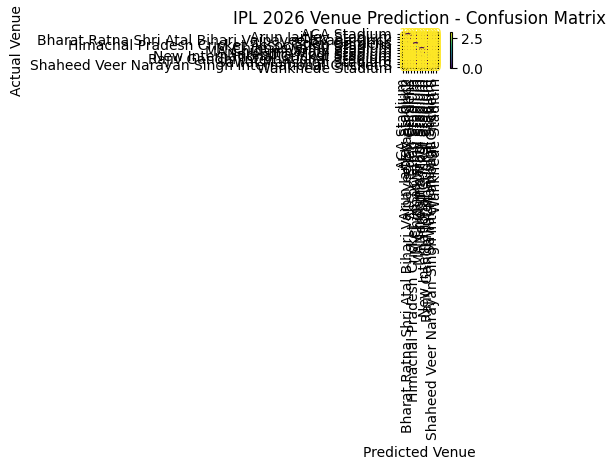

In [38]:
# STEP 12: Confusion Matrix Visualization

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
# Pass the model's classes to ensure the confusion matrix has the same dimensions as the display labels
cm = confusion_matrix(y_test_part, y_pred, labels=evaluation_model.classes_)

# Display confusion matrix
plt.figure(figsize=(12, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=evaluation_model.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("IPL 2026 Venue Prediction - Confusion Matrix")
plt.xlabel("Predicted Venue")
plt.ylabel("Actual Venue")
plt.tight_layout()
plt.show()

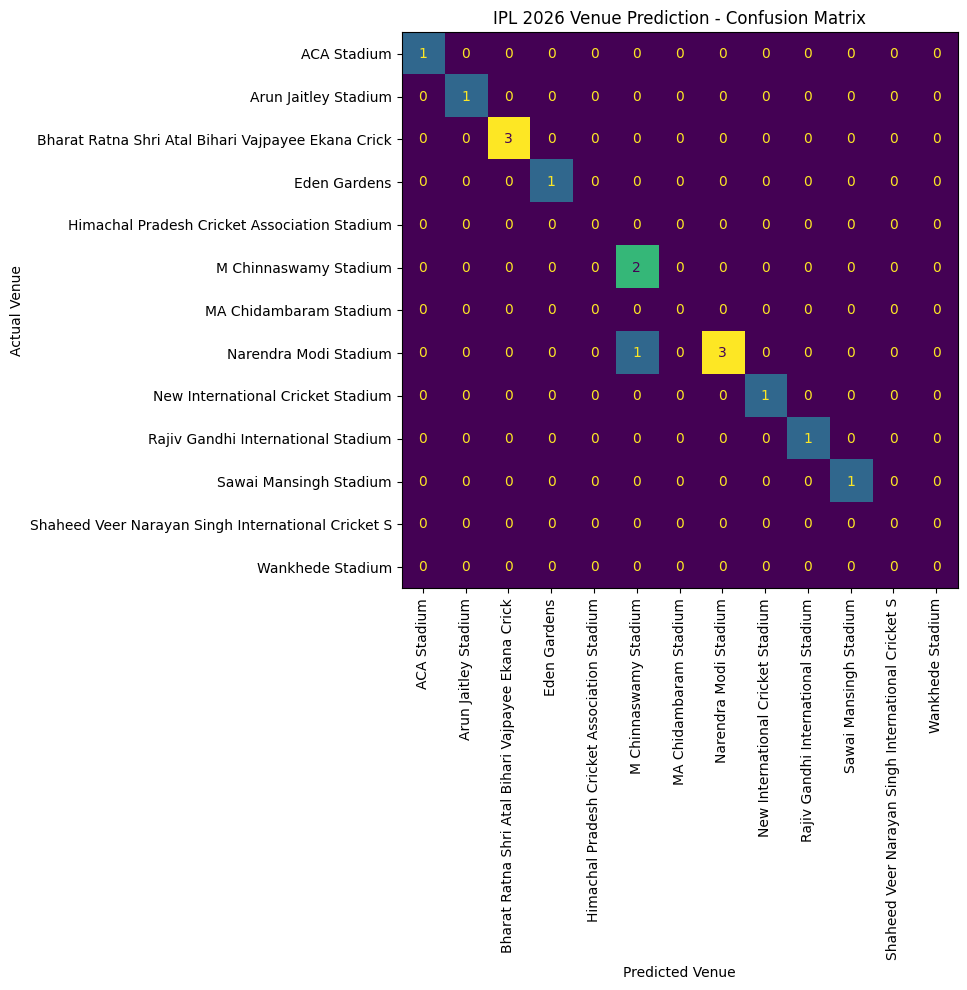

In [39]:
# STEP 12.1: Clean Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=evaluation_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

ax.set_title("IPL 2026 Venue Prediction - Confusion Matrix")
ax.set_xlabel("Predicted Venue")
ax.set_ylabel("Actual Venue")

plt.tight_layout()
plt.show()

In [40]:
# STEP 13: Create Final IPL 2027 Prediction Dataset

final_prediction = final_2027.copy()

# Add prediction status
final_prediction["Prediction Status"] = "ML Predicted - Based on 2026 Data"

# Select final columns
final_prediction = final_prediction[
    [
        "Match ID",
        "Season",
        "Match Number",
        "Round Number",
        "Date",
        "Day Name",
        "Home Team",
        "Away Team",
        "Predicted Location",
        "Prediction Status"
    ]
]

# Sort by date
final_prediction = final_prediction.sort_values("Date")

# Save final CSV
final_prediction.to_csv(
    "IPL_2027_ML_Predicted_Schedule.csv",
    index=False
)

print("======================================")
print("IPL 2027 ML Prediction Completed! ✅")
print("======================================")

print("\nTotal Matches:", len(final_prediction))

print("\nFinal Dataset:")
display(final_prediction.head(10))

print("\nCSV Saved As:")
print("IPL_2027_ML_Predicted_Schedule.csv")

IPL 2027 ML Prediction Completed! ✅

Total Matches: 74

Final Dataset:


,Match ID,Season,Match Number,Round Number,Date,Day Name,Home Team,Away Team,Predicted Location,Prediction Status
0,IPL2027_001,2027,1,1,2027-03-27 14:00:00,Saturday,Royal Challengers Bengaluru,Sunrisers Hyderabad,M Chinnaswamy Stadium,ML Predicted - Based on 2026 Data
1,IPL2027_002,2027,2,1,2027-03-28 14:00:00,Sunday,Mumbai Indians,Kolkata Knight Riders,Wankhede Stadium,ML Predicted - Based on 2026 Data
2,IPL2027_003,2027,3,1,2027-03-29 14:00:00,Monday,Rajasthan Royals,Chennai Super Kings,ACA Stadium,ML Predicted - Based on 2026 Data
3,IPL2027_004,2027,4,1,2027-03-30 14:00:00,Tuesday,Punjab Kings,Gujarat Titans,New International Cricket Stadium,ML Predicted - Based on 2026 Data
4,IPL2027_005,2027,5,1,2027-03-31 14:00:00,Wednesday,Lucknow Super Giants,Delhi Capitals,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,ML Predicted - Based on 2026 Data
5,IPL2027_006,2027,6,1,2027-04-01 14:00:00,Thursday,Kolkata Knight Riders,Sunrisers Hyderabad,Eden Gardens,ML Predicted - Based on 2026 Data
6,IPL2027_007,2027,7,1,2027-04-02 14:00:00,Friday,Chennai Super Kings,Punjab Kings,MA Chidambaram Stadium,ML Predicted - Based on 2026 Data
7,IPL2027_008,2027,8,1,2027-04-03 10:00:00,Saturday,Delhi Capitals,Mumbai Indians,Arun Jaitley Stadium,ML Predicted - Based on 2026 Data
8,IPL2027_009,2027,9,1,2027-04-03 14:00:00,Saturday,Gujarat Titans,Rajasthan Royals,Narendra Modi Stadium,ML Predicted - Based on 2026 Data
9,IPL2027_010,2027,10,2,2027-04-04 10:00:00,Sunday,Sunrisers Hyderabad,Lucknow Super Giants,Rajiv Gandhi International Stadium,ML Predicted - Based on 2026 Data



CSV Saved As:
IPL_2027_ML_Predicted_Schedule.csv
